# Statistiques descriptives

In [1]:
from Bio import SeqIO
from Bio.SeqRecord import SeqRecord
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrow, Patch
import numpy as np
import pandas as pd

In [2]:
CEREVISIAE_PATH = "data/S_cerevisiae.gb"
POMBE_PATH = "data/S_pombe.gb"

In [3]:
record_cerevisiae = SeqIO.read(CEREVISIAE_PATH, "genbank")
record_pombe = SeqIO.read(POMBE_PATH, "genbank")

In [4]:
def extract_features_by_type(genbank_file, record = None, feature_types=["CDS"]):
    if not record :
        record = SeqIO.read(genbank_file, "genbank")
        
    results = {}

    for feature in record.features:
        if feature.type in feature_types:
            sequence = feature.extract(record.seq) if feature.location else None

            annot = {key: value[0] for key, value in feature.qualifiers.items()}
            annot["location"] = str(feature.location)
            if sequence :
                annot["seq_len"] = len(sequence) if sequence else 0
                annot["seq"] = sequence

            if feature.type not in results:
                results[feature.type] = []

            results[feature.type].append(annot)

    return results

In [5]:
features_cerevisiae = extract_features_by_type(None, record_cerevisiae, ['gene', 'CDS', 'tRNA', 'rRNA'])
features_pombe = extract_features_by_type(None, record_pombe, ['gene', 'CDS', 'tRNA', 'rRNA'])

In [6]:
print(f"S. cerevisiae - numéro d'accession : {record_cerevisiae.name}")
print(f"S. pombe - numéro d'accession : {record_pombe.name}")

S. cerevisiae - numéro d'accession : NC_027264
S. pombe - numéro d'accession : NC_088682


In [7]:
# Longueur totale de la séquence
# Utile pour donner une idée de la taille globale et de l'importance des insertions / duplications / pertes
print(f"S. cerevisiae - Taille du génome : {len(record_cerevisiae.seq)} pb")
print(f"S. pombe - Taille du génome : {len(record_pombe.seq)} pb")

S. cerevisiae - Taille du génome : 78917 pb
S. pombe - Taille du génome : 19433 pb


In [8]:
# % GC du génome
# Reflète les contraintes structurales et évolutives. Permet  d'identifier des adaotations ou mutations
gc_cerevisiae = float(record_cerevisiae.seq.count("G") + record_cerevisiae.seq.count("C")) / len(record_cerevisiae.seq) * 100
gc_pombe = float(record_pombe.seq.count("G") + record_pombe.seq.count("C")) / len(record_pombe.seq) * 100

print(f"S. cerevisiae - Proportion GC : {gc_cerevisiae:.2f}%")
print(f"S. pombe - Proportion GC : {gc_pombe:.2f}%")

S. cerevisiae - Proportion GC : 16.13%
S. pombe - Proportion GC : 30.07%


In [9]:
# Nombre total de gènes
# Permet de voir les gènes perdus ou acquis
print(f"S. cerevisiae - Nombre total de gènes : {len(features_cerevisiae['gene'])}")
print(f"S. pombe - Nombre total de gènes : {len(features_pombe['gene'])}")

S. cerevisiae - Nombre total de gènes : 35
S. pombe - Nombre total de gènes : 39


In [10]:
# Nombre d'ARNr
# Permet de vérifier la conservation des composants ribosomiques (typiquement 2 - (12S et 16S))
print(f"S. cerevisiae - Nombre d'ARNr : {len(features_cerevisiae['rRNA'])}")
print(f"S. pombe - Nombre d'ARNr : {len(features_pombe['rRNA'])}")

S. cerevisiae - Nombre d'ARNr : 2
S. pombe - Nombre d'ARNr : 2


In [11]:
# Nombre d'ARNt
# Permet de vérifier la complétude du système de traduction mitochondrial et si l'espèce importe du noyau certains ARNt
print(f"S. cerevisiae - Nombre d'ARNt : {len(features_cerevisiae['tRNA'])}")
print(f"S. pombe - Nombre d'ARNt : {len(features_pombe['tRNA'])}")

S. cerevisiae - Nombre d'ARNt : 24
S. pombe - Nombre d'ARNt : 25


In [12]:
# Nombre de CDS
# Permet de connaître la capacité de codage protéique et s'il y a de potentielles pertes de fonctions métaboliques
print(f"S. cerevisiae - Nombre de CDS : {len(features_cerevisiae['CDS'])}")
print(f"S. pombe - Nombre de CDS : {len(features_pombe['CDS'])}")

S. cerevisiae - Nombre de CDS : 8
S. pombe - Nombre de CDS : 11


In [13]:
# Densité génétique
# Permet de mesurer l'efficacité de codage du génome mitochondrial.
total_len_cerevisiae = sum(feat["seq_len"] for feat in features_cerevisiae['gene'])
total_len_pombe = sum(feat["seq_len"] for feat in features_pombe['gene'])

print(f"S. cerevisiae - Densité génique : {(total_len_cerevisiae / len(record_cerevisiae.seq) * 100):.2f}%")
print(f"S. pombe - Densité génique : {(total_len_pombe / len(record_pombe.seq) * 100):.2f}%")

S. cerevisiae - Densité génique : 33.83%
S. pombe - Densité génique : 112.76%


In [14]:
def plot_coding_sequences_linear(record, species_name):
    fig, ax = plt.subplots(figsize=(12, 3))
    genome_length = len(record.seq)

    color_map = {
        "CDS": "red",
        "tRNA": "green",
        "rRNA": "blue"
    }
    
    feature_types=["CDS", "tRNA", "rRNA"]

    tracks = []

    for feature in record.features:
        if feature.type not in feature_types:
            continue
        start = int(feature.location.start)
        end = int(feature.location.end)
        strand = feature.location.strand

        # Trouver une piste sans chevauchement
        for i, track in enumerate(tracks):
            if all(end < s or start > e for (s, e) in track):
                track.append((start, end))
                y_pos = i + 1
                break
        else:
            # Nouvelle piste
            tracks.append([(start, end)])
            y_pos = len(tracks)

        arrow = FancyArrow(
            start, y_pos, end - start, 0,
            width = 0.3,
            head_width = 0.5,
            head_length = min(100, end - start),
            length_includes_head = True,
            color = color_map.get(feature.type, "gray")
        )
        ax.add_patch(arrow)

        if feature.type == "CDS" :
            label = feature.qualifiers.get("gene", [""])[0]
            ax.text((start + end) / 2, y_pos + 0.5, label, ha='center', fontsize=8, rotation=90)

    ax.set_xlim(0, genome_length)
    ax.set_ylim(0, len(tracks)+2)
    ax.set_yticks([])
    ax.set_title(f"Répartition des CDS, ARNt et ARNr dans le génome mitochondrial de {species_name}")
    ax.set_xlabel("Position (pb)")
    plt.legend(
        [Patch(color="red"), Patch(color="green"), Patch(color="blue")],
        ["CDS", "ARNt", "ARNr"],
        loc="upper right"
    )
    plt.tight_layout()
    plt.show()

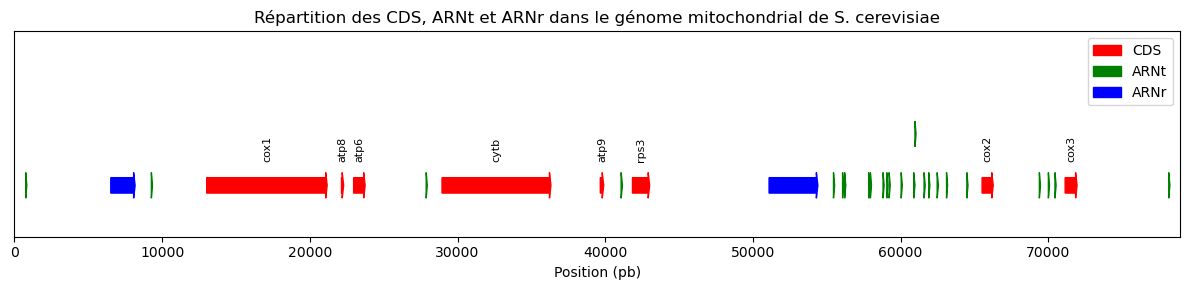

In [15]:
plot_coding_sequences_linear(record_cerevisiae, "S. cerevisiae")

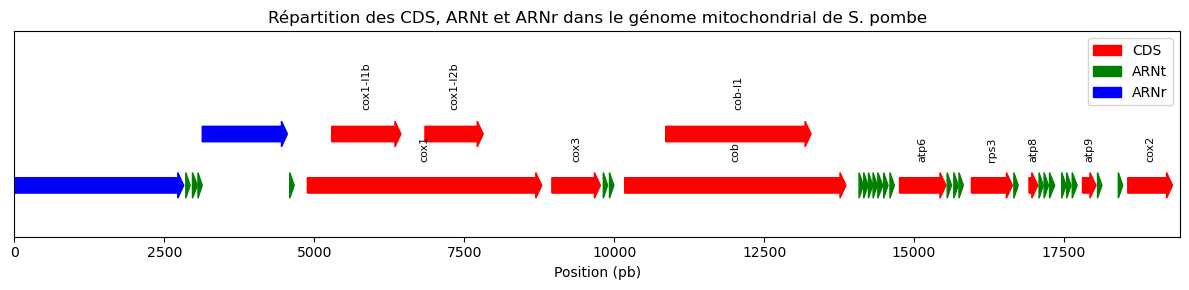

In [16]:
plot_coding_sequences_linear(record_pombe, "S. pombe")

In [17]:
# Répartition des gènes codants par brin
# Permet de voir l'asymétrie fonctionnelle ou transcriptionnelle
def extract_strand_counts(features):
    strand_counts = {"+" : 0, "-": 0}

    for feat in features:
        if "(+)" in feat.get("location") : 
            strand_counts["+"] += 1
        else :
            strand_counts["-"] += 1

    return strand_counts

print(f"S. cerevisiae - Répartition des gènes par brin : {extract_strand_counts(features_cerevisiae['gene'])}")
print(f"S. pombe - Répartition des gènes par brin : {extract_strand_counts(features_pombe['gene'])}")

S. cerevisiae - Répartition des gènes par brin : {'+': 34, '-': 1}
S. pombe - Répartition des gènes par brin : {'+': 39, '-': 0}


In [18]:
# Correspondance des gènes
set_cerevisiae = set([g['gene'] for g in features_cerevisiae['CDS']])
set_pombe = set([g['gene'] for g in features_pombe['CDS']])

all_genes = sorted(set_cerevisiae.union(set_pombe))

line_cerevisiae = [gene if gene in set_cerevisiae else " " * len(gene) for gene in all_genes]
line_pombe = [gene if gene in set_pombe else " " * len(gene) for gene in all_genes]

separator = " | "
print("\n")
print("Correspondance des gènes mitochondriaux :")
print("S. cerevisiae :", separator.join(line_cerevisiae))
print("S. pombe      :", separator.join(line_pombe))
print("\n")



Correspondance des gènes mitochondriaux :
S. cerevisiae : atp6 | atp8 | atp9 |     |        | cox1 |          |          | cox2 | cox3 | cytb | rps3
S. pombe      : atp6 | atp8 | atp9 | cob | cob-I1 | cox1 | cox1-I1b | cox1-I2b | cox2 | cox3 |      | rps3




In [19]:
def extract_length_stats(features):
    lengths = [seq["seq_len"] for seq in features]

    return {
        "min"   : int(np.min(lengths)),
        "mean"  : float(round(np.mean(lengths), 2)),
        "median": float(round(np.median(lengths), 2)),
        "max"   : int(np.max(lengths))
    }

In [20]:
# Statistiques de longueur des CDS
# Permet d'évaluer la complexité ou fragmentation des gènes
print(f"S. cerevisiae - Statistiques de longueur des CDS : {extract_length_stats(features_cerevisiae['CDS'])}")
print(f"S. pombe -  Statistiques de longueur des CDS : {extract_length_stats(features_pombe['CDS'])}")

S. cerevisiae - Statistiques de longueur des CDS : {'min': 147, 'mean': 831.38, 'median': 795.0, 'max': 1605}
S. pombe -  Statistiques de longueur des CDS : {'min': 147, 'mean': 974.45, 'median': 810.0, 'max': 2424}


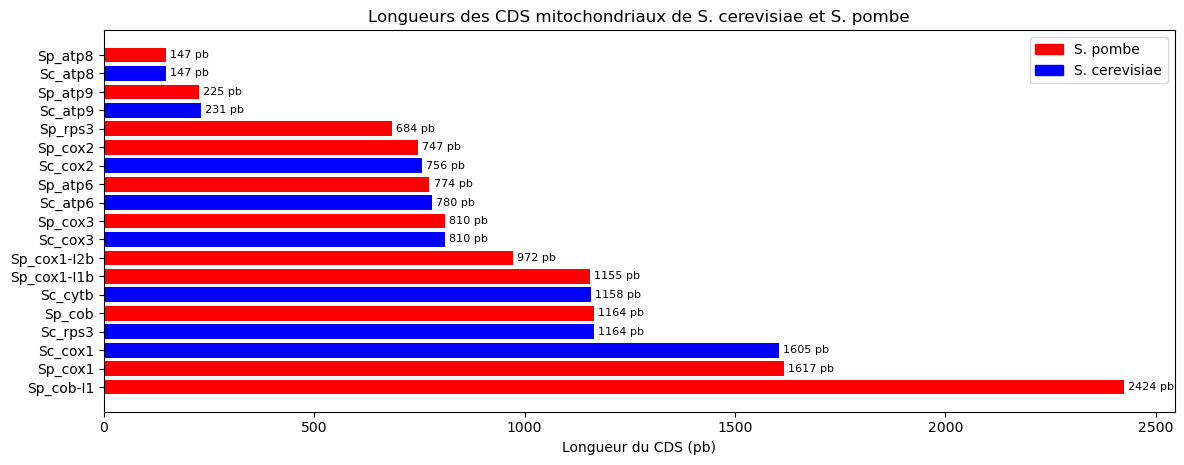

In [21]:
# Graphique des longueurs des CDS
# Permet de visualiser la distribution des longueurs et facilite la comparaison entre espèces
def prepare_cds_data(cds_list, prefix):
    data = []
    for i, cds in enumerate(cds_list):
        gene = cds.get("gene", f"CDS_{i}")
        name = f"{prefix}_{gene}"
        data.append((name, cds["seq_len"]))
    return data

data_cerevisiae = prepare_cds_data(features_cerevisiae['CDS'], "Sc")
data_pombe = prepare_cds_data(features_pombe['CDS'], "Sp")

all_data = data_cerevisiae + data_pombe
all_data.sort(key=lambda x: x[1], reverse=True)

labels, lengths = zip(*all_data)
colors = ['blue' if label.startswith("Sc_") else 'red' for label in labels]

plt.figure(figsize=(12, len(labels) * 0.25))
bars = plt.barh(labels, lengths, color=colors)

for bar, length in zip(bars, lengths):
    plt.text(length + 10, bar.get_y() + bar.get_height() / 2,
             f"{length} pb", va='center', fontsize=8)

plt.xlabel("Longueur du CDS (pb)")
plt.title("Longueurs des CDS mitochondriaux de S. cerevisiae et S. pombe")
plt.tight_layout()
plt.legend(
        [Patch(color="red"), Patch(color="blue")],
        ["S. pombe", "S. cerevisiae"],
        loc="upper right"
    )
plt.show()